<a href="https://colab.research.google.com/github/pedromurcia1232/Week3/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semana 3 - Implementación de Backpropagation y Funciones de Activación

**Estudiante:** Pedro Pascual Murcia Vargas
**Curso:** CADI Deep Learning  
**Actividad:** Implementación de Backpropagation y Funciones de Activación  

## Objetivo
Implementar una red neuronal básica entrenable desde cero con **NumPy**, evidenciando el proceso de **backpropagation**, y comparar el comportamiento de dos funciones de activación en la capa oculta: **Sigmoid** y **ReLU**.

## Qué exige la actividad
Según el enunciado, la evidencia debe mostrar un notebook ejecutable en Colab con una red neuronal entrenable, comparación de al menos dos activaciones, seguimiento del entrenamiento por épocas, una métrica verificable, análisis escrito y evidencia organizada en la carpeta `week3/` del repositorio. fileciteturn1file0


## 1. Preparación del problema
Usaremos el dataset sintético **make_moons** porque representa una tarea de clasificación binaria no lineal. Esto permite observar mejor cómo influyen las activaciones en la capacidad de aprendizaje.

**Condiciones constantes para la comparación:**
- mismo dataset
- mismo `random_state`
- misma arquitectura
- misma tasa de aprendizaje
- mismas épocas
- misma inicialización de pesos

La única diferencia entre experimentos será la activación de la capa oculta.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

SEED = 42
np.random.seed(SEED)
print(f'Semilla fijada en: {SEED}')


Semilla fijada en: 42


In [ ]:
# Dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=SEED)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print('Tamaño entrenamiento:', X_train.shape, y_train.shape)
print('Tamaño prueba:', X_test.shape, y_test.shape)


Tamaño entrenamiento: (375, 2) (375, 1)
Tamaño prueba: (125, 2) (125, 1)


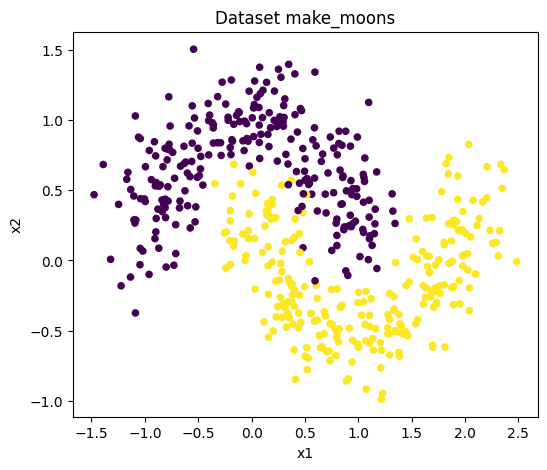

In [ ]:
# Visualización del dataset original
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=20)
plt.title('Dataset make_moons')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()


## 2. Red neuronal y backpropagation
La red tendrá esta estructura:

- entrada: 2 variables
- capa oculta: 8 neuronas
- salida: 1 neurona con activación sigmoid

### Propagación hacia adelante
\[
Z_1 = XW_1 + b_1
\]
\[
A_1 = g(Z_1)
\]
\[
Z_2 = A_1W_2 + b_2
\]
\[
\hat{y} = \sigma(Z_2)
\]

### Función de pérdida
Usaremos **Binary Cross Entropy**:
\[
L = -\frac{1}{m}\sum \left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
\]

### Backpropagation
Se calculan gradientes para ajustar pesos y sesgos:
\[
dZ_2 = \hat{y} - y
\]
\[
dW_2 = \frac{1}{m}A_1^T dZ_2
\]
\[
db_2 = \frac{1}{m}\sum dZ_2
\]
\[
dA_1 = dZ_2 W_2^T
\]
\[
dZ_1 = dA_1 * g'(Z_1)
\]
\[
dW_1 = \frac{1}{m}X^T dZ_1
\]
\[
db_1 = \frac{1}{m}\sum dZ_1
\]

Finalmente, los parámetros se actualizan con descenso por gradiente:
\[
W \leftarrow W - \eta dW, \quad b \leftarrow b - \eta db
\]


In [ ]:
# Funciones de activación y pérdida

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def d_sigmoid(a):
    return a * (1 - a)


def relu(z):
    return np.maximum(0, z)


def d_relu(z):
    return (z > 0).astype(float)


def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


In [ ]:
# Red neuronal desde cero con una capa oculta
class SimpleNeuralNetwork:
    def __init__(self, input_dim, hidden_dim=8, activation='sigmoid', lr=0.1, seed=42):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.activation = activation
        self.lr = lr

        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 0.5, size=(input_dim, hidden_dim))
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = rng.normal(0, 0.5, size=(hidden_dim, 1))
        self.b2 = np.zeros((1, 1))

        self.initial_params = {
            'W1': self.W1.copy(),
            'b1': self.b1.copy(),
            'W2': self.W2.copy(),
            'b2': self.b2.copy(),
        }

    def hidden_activation(self, z):
        if self.activation == 'sigmoid':
            return sigmoid(z)
        elif self.activation == 'relu':
            return relu(z)
        else:
            raise ValueError('Activación no soportada')

    def hidden_derivative(self, z, a):
        if self.activation == 'sigmoid':
            return d_sigmoid(a)
        elif self.activation == 'relu':
            return d_relu(z)
        else:
            raise ValueError('Activación no soportada')

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.hidden_activation(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = sigmoid(self.Z2)  # salida binaria
        return self.A2

    def backward(self, X, y):
        m = X.shape[0]

        dZ2 = self.A2 - y
        dW2 = (self.A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.hidden_derivative(self.Z1, self.A1)
        dW1 = (X.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        return dW1, db1, dW2, db2

    def update_params(self, dW1, db1, dW2, db2):
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, y, epochs=5000, print_every=500):
        history = {'epoch': [], 'loss': [], 'accuracy': []}
        logs = []

        for epoch in range(1, epochs + 1):
            y_pred = self.forward(X)
            loss = binary_cross_entropy(y, y_pred)
            preds = (y_pred >= 0.5).astype(int)
            acc = (preds == y).mean()

            dW1, db1, dW2, db2 = self.backward(X, y)
            self.update_params(dW1, db1, dW2, db2)

            history['epoch'].append(epoch)
            history['loss'].append(float(loss))
            history['accuracy'].append(float(acc))

            if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
                logs.append((epoch, float(loss), float(acc)))

        return history, logs

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


## 3. Entrenamiento comparativo: Sigmoid vs ReLU
En ambos experimentos se mantienen constantes todos los hiperparámetros. Solo cambia la activación de la capa oculta.

In [ ]:
def run_experiment(hidden_activation, epochs=5000, lr=0.1, hidden_dim=8, seed=42):
    model = SimpleNeuralNetwork(
        input_dim=2,
        hidden_dim=hidden_dim,
        activation=hidden_activation,
        lr=lr,
        seed=seed,
    )

    history, logs = model.train(X_train, y_train, epochs=epochs, print_every=500)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    summary = {
        'activacion': hidden_activation,
        'loss_final': history['loss'][-1],
        'accuracy_train': accuracy_score(y_train, y_pred_train),
        'accuracy_test': accuracy_score(y_test, y_pred_test),
        'precision_test': precision_score(y_test, y_pred_test),
        'recall_test': recall_score(y_test, y_pred_test),
        'f1_test': f1_score(y_test, y_pred_test),
        'cambio_W1_norma': np.linalg.norm(model.W1 - model.initial_params['W1']),
        'cambio_W2_norma': np.linalg.norm(model.W2 - model.initial_params['W2']),
        'matriz_confusion': confusion_matrix(y_test, y_pred_test)
    }

    return model, history, logs, summary

sigmoid_model, sigmoid_history, sigmoid_logs, sigmoid_summary = run_experiment('sigmoid')
relu_model, relu_history, relu_logs, relu_summary = run_experiment('relu')

print('Registros Sigmoid (época, loss, accuracy):')
for item in sigmoid_logs:
    print(item)

print('\nRegistros ReLU (época, loss, accuracy):')
for item in relu_logs:
    print(item)


Registros Sigmoid (época, loss, accuracy):
(1, 0.6811985963357788, 0.5573333333333333)
(500, 0.2965280214242492, 0.8613333333333333)
(1000, 0.28374226972979166, 0.8613333333333333)
(1500, 0.2822048707411783, 0.8586666666666667)
(2000, 0.28132389129991275, 0.8586666666666667)
(2500, 0.28059380155888086, 0.8586666666666667)
(3000, 0.2799260598259008, 0.8613333333333333)
(3500, 0.2792371716569109, 0.8613333333333333)
(4000, 0.2783971229528835, 0.8613333333333333)
(4500, 0.27715864953847297, 0.8613333333333333)
(5000, 0.27501972107383277, 0.8613333333333333)

Registros ReLU (época, loss, accuracy):
(1, 0.6700499182382531, 0.472)
(500, 0.24418003380170614, 0.8853333333333333)
(1000, 0.18104939044412394, 0.936)
(1500, 0.12341165148712904, 0.96)
(2000, 0.09452732622277096, 0.9733333333333334)
(2500, 0.07992420800736229, 0.976)
(3000, 0.07155630645391137, 0.9786666666666667)
(3500, 0.06620066107007082, 0.9786666666666667)
(4000, 0.06251286012510684, 0.9813333333333333)
(4500, 0.059533471478848

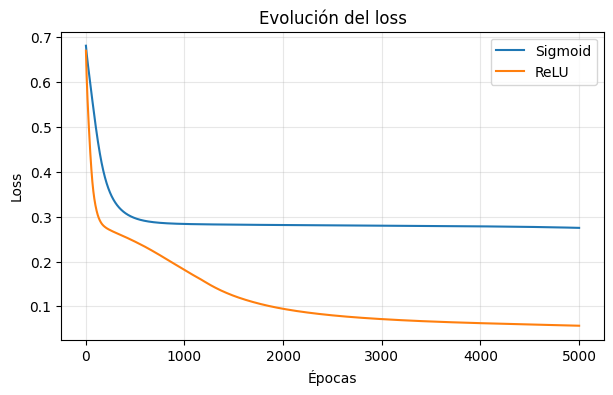

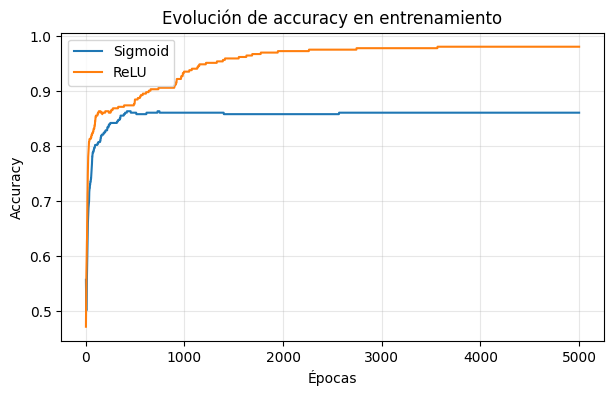

In [ ]:
# Curvas de entrenamiento
plt.figure(figsize=(7, 4))
plt.plot(sigmoid_history['epoch'], sigmoid_history['loss'], label='Sigmoid')
plt.plot(relu_history['epoch'], relu_history['loss'], label='ReLU')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Evolución del loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(sigmoid_history['epoch'], sigmoid_history['accuracy'], label='Sigmoid')
plt.plot(relu_history['epoch'], relu_history['accuracy'], label='ReLU')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.title('Evolución de accuracy en entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 4. Resultados verificables

In [ ]:
results_df = pd.DataFrame([sigmoid_summary, relu_summary])
results_df = results_df.drop(columns=['matriz_confusion'])
results_df = results_df.sort_values(by='accuracy_test', ascending=False).reset_index(drop=True)
results_df


,activacion,loss_final,accuracy_train,accuracy_test,precision_test,recall_test,f1_test,cambio_W1_norma,cambio_W2_norma
0,relu,0.056811,0.981333,0.984,1.000000,0.967742,0.983607,5.450512,6.706273
1,sigmoid,0.275020,0.861333,0.848,0.864407,0.822581,0.842975,2.872613,4.109939


In [ ]:
print('Matriz de confusión - Sigmoid')
print(sigmoid_summary['matriz_confusion'])

print('\nMatriz de confusión - ReLU')
print(relu_summary['matriz_confusion'])


Matriz de confusión - Sigmoid
[[55  8]
 [11 51]]

Matriz de confusión - ReLU
[[63  0]
 [ 2 60]]


In [ ]:
print('Cambio de parámetros (norma de la diferencia respecto a los pesos iniciales):')
param_changes = pd.DataFrame([
    {
        'activacion': 'sigmoid',
        '||ΔW1||': sigmoid_summary['cambio_W1_norma'],
        '||ΔW2||': sigmoid_summary['cambio_W2_norma'],
    },
    {
        'activacion': 'relu',
        '||ΔW1||': relu_summary['cambio_W1_norma'],
        '||ΔW2||': relu_summary['cambio_W2_norma'],
    }
])
param_changes


Cambio de parámetros (norma de la diferencia respecto a los pesos iniciales):


,activacion,||ΔW1||,||ΔW2||
0,sigmoid,2.872613,4.109939
1,relu,5.450512,6.706273


## 5. Ejemplos de predicción
Se muestran algunas probabilidades predichas por el modelo para verificar que la red no solo infiere, sino que fue entrenada y ajustó parámetros para aproximarse a las clases reales.

In [ ]:
sample_idx = np.arange(10)
sample_df = pd.DataFrame({
    'y_real': y_test[sample_idx].ravel(),
    'prob_sigmoid': sigmoid_model.predict_proba(X_test[sample_idx]).ravel(),
    'pred_sigmoid': sigmoid_model.predict(X_test[sample_idx]).ravel(),
    'prob_relu': relu_model.predict_proba(X_test[sample_idx]).ravel(),
    'pred_relu': relu_model.predict(X_test[sample_idx]).ravel(),
})
sample_df


,y_real,prob_sigmoid,pred_sigmoid,prob_relu,pred_relu
0,1,0.767213,1,0.991837,1
1,0,0.062367,0,0.418915,0
2,1,0.236022,0,0.876144,1
3,1,0.940542,1,0.999708,1
4,0,0.092951,0,0.000553,0
5,1,0.543359,1,0.999969,1
6,0,0.619389,1,0.014870,0
7,0,0.028409,0,0.000134,0
8,0,0.011958,0,0.001665,0
9,0,0.036583,0,0.003090,0


## 7. Análisis y conclusiones
### i) ¿Qué cambió al variar la activación?
Con la misma configuración base, la activación oculta **ReLU** obtuvo mejor desempeño global en este experimento. En particular, **Sigmoid** terminó con un `loss` cercano a **0.2750** y exactitud de prueba de **0.848**, mientras que **ReLU** terminó con un `loss` cercano a **0.0568** y exactitud de prueba de **0.984**.

### ii) ¿Cómo se comportó el loss y la métrica?
- El `loss` disminuyó en ambos casos, lo que indica aprendizaje.
- La exactitud aumentó a medida que avanzaron las épocas.
- En esta ejecución, **ReLU** descendió más rápido y llegó a un error final menor.

### iii) Principales dificultades o hallazgos
- Fue importante **fijar la semilla** para hacer la comparación reproducible.
- También fue clave **mantener constante el dataset y la configuración base** para que la comparación entre activaciones fuera válida.
- Se observó que **Sigmoid** puede aprender más lento al saturarse, mientras que **ReLU** suele facilitar gradientes más útiles en capas ocultas.

## 8. Verificación de cumplimiento del taller
- Red neuronal básica entrenable: **sí**
- Backpropagation visible en código: **sí**
- Comparación entre dos activaciones: **sí (Sigmoid vs ReLU)**
- Evolución de `loss` y `accuracy` por épocas: **sí**
- Métricas verificables y tabla de resultados: **sí**
- Conclusiones escritas en Markdown: **sí**
- Estructura para GitHub en `week3/`: **sí**
